## Preparation of subset

As our dataset consists of 151 images in total, but ther size is 1500x1500, we can use patches. So, we cut each 1500x1500 image and its mask into identical small patches. We crop the image and the mask using the same coordinates.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

TRAIN_DIR = RAW_DIR / "train"
TRAIN_LABELS_DIR = RAW_DIR / "train_labels"

VAL_DIR = RAW_DIR / "val"
VAL_LABELS_DIR = RAW_DIR / "val_labels"

TEST_DIR = RAW_DIR / "test"
TEST_LABELS_DIR = RAW_DIR / "test_labels"

In [4]:
PATCH_SIZE = 256 
TARGET_SIZE = 1536

In [5]:
def pad_to_target(array, target_size=TARGET_SIZE):
    height, width = array.shape[:2]

    pad_height = target_size - height
    pad_width = target_size - width

    padded = np.pad(
        array,
        (
            (0, pad_height),
            (0, pad_width),
            (0, 0)
        ),
        mode="constant",
        constant_values=0
    )

    return padded

sample_image_path = next(TRAIN_DIR.glob("*.png"))
sample_mask_path = TRAIN_LABELS_DIR / sample_image_path.name

image = np.array(Image.open(sample_image_path))
mask = np.array(Image.open(sample_mask_path))

print("Original image shape:", image.shape)
print("Original mask shape:", mask.shape)

padded_image = pad_to_target(image)
padded_mask = pad_to_target(mask)

print("Padded image shape:", padded_image.shape)
print("Padded mask shape:", padded_mask.shape)

Original image shape: (1500, 1500, 3)
Original mask shape: (1500, 1500, 3)
Padded image shape: (1536, 1536, 3)
Padded mask shape: (1536, 1536, 3)


In [6]:
def split_into_patches(array, patch_size=PATCH_SIZE):
    patches = []

    height, width = array.shape[:2]

    for y in range(0, height, patch_size):
        for x in range(0, width, patch_size):
            patch = array[
                y:y + patch_size,
                x:x + patch_size
            ]

            patches.append(patch)

    return patches

image_patches = split_into_patches(padded_image)
mask_patches = split_into_patches(padded_mask)

print("Number of image patches:", len(image_patches))
print("Number of mask patches:", len(mask_patches))

print("One image patch shape:", image_patches[0].shape)
print("One mask patch shape:", mask_patches[0].shape)

Number of image patches: 36
Number of mask patches: 36
One image patch shape: (256, 256, 3)
One mask patch shape: (256, 256, 3)


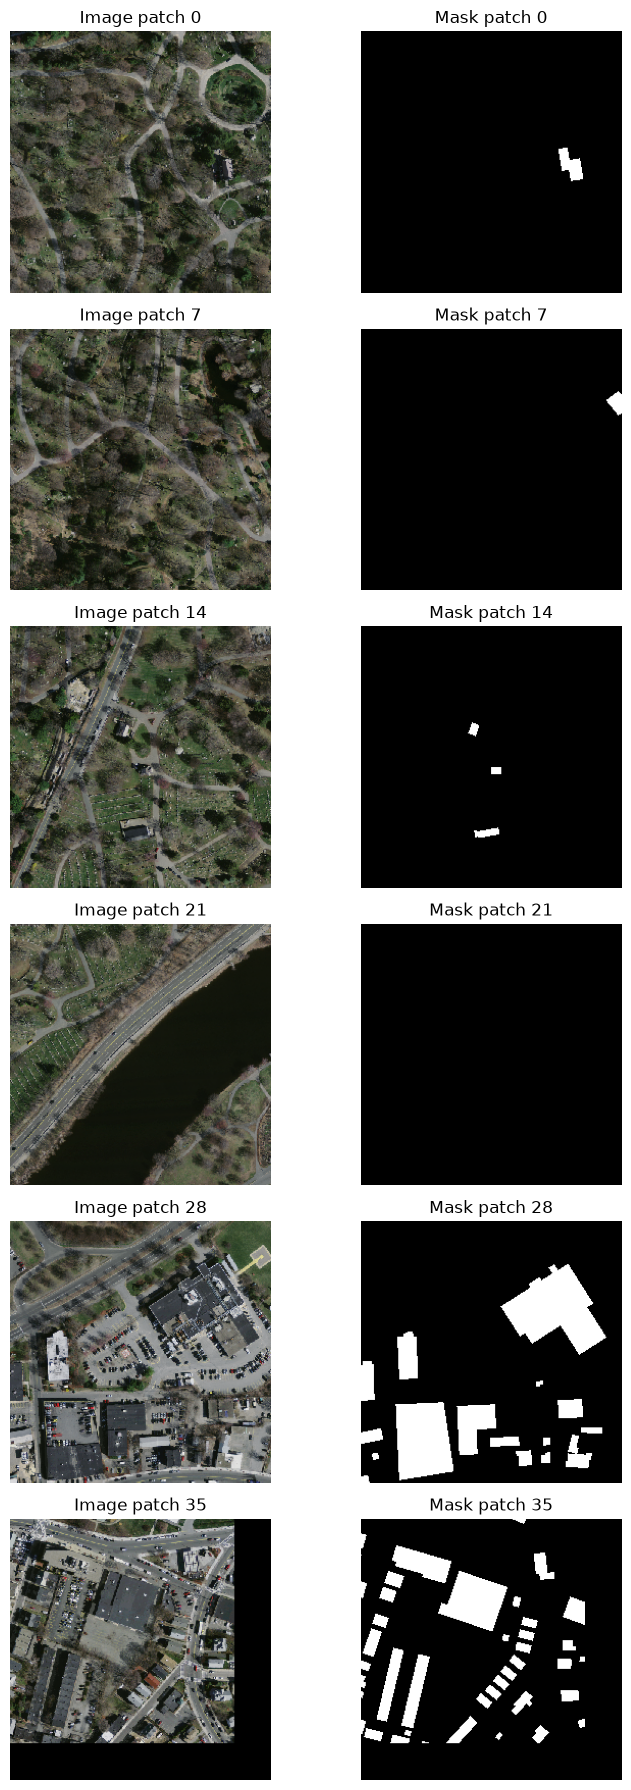

In [7]:
indices_to_show = [0, 7, 14, 21, 28, 35]

fig, axes = plt.subplots(len(indices_to_show), 2, figsize=(8, 3 * len(indices_to_show)))

for row, idx in enumerate(indices_to_show):
    axes[row, 0].imshow(image_patches[idx])
    axes[row, 0].set_title(f"Image patch {idx}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(mask_patches[idx])
    axes[row, 1].set_title(f"Mask patch {idx}")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

In [9]:
def get_building_fraction(mask_patch):
    # All three RGB channels contain the same mask,
    # so we use only one channel.
    binary_mask = mask_patch[:, :, 0] > 0

    return binary_mask.mean()

import pandas as pd

def collect_patch_statistics(images_dir, masks_dir, split_name):
    records = []

    image_paths = sorted(images_dir.glob("*.png"))

    for image_path in image_paths:
        mask_path = masks_dir / image_path.name

        image = np.array(Image.open(image_path))
        mask = np.array(Image.open(mask_path))

        padded_image = pad_to_target(image)
        padded_mask = pad_to_target(mask)

        image_patches = split_into_patches(padded_image)
        mask_patches = split_into_patches(padded_mask)

        for patch_idx, mask_patch in enumerate(mask_patches):
            building_fraction = get_building_fraction(mask_patch)

            records.append({
                "split": split_name,
                "source_image": image_path.name,
                "patch_idx": patch_idx,
                "building_fraction": building_fraction,
            })

    return pd.DataFrame(records)

In [10]:
train_stats = collect_patch_statistics(
    TRAIN_DIR,
    TRAIN_LABELS_DIR,
    "train"
)

val_stats = collect_patch_statistics(
    VAL_DIR,
    VAL_LABELS_DIR,
    "val"
)

test_stats = collect_patch_statistics(
    TEST_DIR,
    TEST_LABELS_DIR,
    "test"
)

patch_stats = pd.concat(
    [train_stats, val_stats, test_stats],
    ignore_index=True
)

patch_stats.head()

,split,source_image,patch_idx,building_fraction
0,train,22678915_15.png,0,0.045395
1,train,22678915_15.png,1,0.307648
2,train,22678915_15.png,2,0.150574
3,train,22678915_15.png,3,0.210464
4,train,22678915_15.png,4,0.087860


In [15]:
print("Total patches:", len(patch_stats))

print("\nPatches by split:")
print(patch_stats["split"].value_counts())

empty_by_split = (
    patch_stats
    .assign(empty=patch_stats["building_fraction"] == 0)
    .groupby("split")["empty"]
    .agg(["sum", "count", "mean"])
)

empty_by_split["percentage"] = empty_by_split["mean"] * 100

empty_by_split



Total patches: 5436

Patches by split:
split
train    4932
test      360
val       144
Name: count, dtype: int64


,sum,count,mean,percentage
split,,,,
test,26,360,0.072222,7.222222
train,571,4932,0.115775,11.577453
val,9,144,0.062500,6.250000


In [16]:
patch_stats["building_fraction"].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]
)

count    5436.000000
mean        0.128676
std         0.101936
min         0.000000
10%         0.000000
25%         0.045021
50%         0.118813
75%         0.192829
90%         0.259834
max         0.961273
Name: building_fraction, dtype: float64

In [17]:
SPLITS_DIR = PROJECT_ROOT / "data" / "splits"

for split in ["train", "val", "test"]:
    (PROCESSED_DIR / split / "images").mkdir(parents=True, exist_ok=True)
    (PROCESSED_DIR / split / "masks").mkdir(parents=True, exist_ok=True)

SPLITS_DIR.mkdir(parents=True, exist_ok=True)

print("Processed data directories are ready.")

Processed data directories are ready.


In [18]:
def process_and_save_split(images_dir, masks_dir, split_name):
    records = []

    output_images_dir = PROCESSED_DIR / split_name / "images"
    output_masks_dir = PROCESSED_DIR / split_name / "masks"

    image_paths = sorted(images_dir.glob("*.png"))

    for image_path in image_paths:
        mask_path = masks_dir / image_path.name

        image = np.array(Image.open(image_path))
        mask = np.array(Image.open(mask_path))

        padded_image = pad_to_target(image)
        padded_mask = pad_to_target(mask)

        image_patches = split_into_patches(padded_image)
        mask_patches = split_into_patches(padded_mask)

        for patch_idx, (image_patch, mask_patch) in enumerate(
            zip(image_patches, mask_patches)
        ):
            patch_name = f"{image_path.stem}_patch_{patch_idx:02d}.png"

            image_output_path = output_images_dir / patch_name
            mask_output_path = output_masks_dir / patch_name

            # Save the RGB aerial image.
            Image.fromarray(image_patch).save(image_output_path)

            # All RGB mask channels are identical,
            # so only one channel is needed.
            binary_mask = mask_patch[:, :, 0]

            Image.fromarray(binary_mask).save(mask_output_path)

            building_fraction = (binary_mask > 0).mean()

            records.append({
                "split": split_name,
                "source_image": image_path.name,
                "patch_idx": patch_idx,
                "image_path": str(image_output_path.relative_to(PROJECT_ROOT)),
                "mask_path": str(mask_output_path.relative_to(PROJECT_ROOT)),
                "building_fraction": building_fraction,
            })

    return pd.DataFrame(records)

In [19]:
train_processed = process_and_save_split(
    TRAIN_DIR,
    TRAIN_LABELS_DIR,
    "train"
)

val_processed = process_and_save_split(
    VAL_DIR,
    VAL_LABELS_DIR,
    "val"
)

test_processed = process_and_save_split(
    TEST_DIR,
    TEST_LABELS_DIR,
    "test"
)

In [21]:
train_processed.to_csv(
    SPLITS_DIR / "train.csv",
    index=False
)

val_processed.to_csv(
    SPLITS_DIR / "val.csv",
    index=False
)

test_processed.to_csv(
    SPLITS_DIR / "test.csv",
    index=False
)

print("Split CSV files saved.")

Split CSV files saved.


## Patch subset summary

The original 1500 × 1500 images were padded to 1536 × 1536 and divided
into non-overlapping 256 × 256 patches.

The original train/validation/test partition was preserved to prevent
data leakage. All patches originating from the same source image therefore
remain in the same split.

The resulting dataset contains:

- 4,932 training patches
- 144 validation patches
- 360 test patches
- 5,436 patches in total

The distribution of building coverage was inspected before selecting the
final subset. Background-only patches were not dominant, while the dataset
also contained patches with low, medium, and high building coverage.

Therefore, no additional filtering based on building coverage was applied.
All generated patches were retained. Background-only patches provide valid
negative examples, while patches with very small building regions are
particularly important for evaluating segmentation of small buildings.